In [2]:
%load_ext autoreload
%autoreload 2

import gc
import logging
from pathlib import Path

import shap
import xgboost as xgb
from dask.distributed import Client, LocalCluster
from Experiment import Experiment
from newutils.data.Dataset import Dataset
from newutils.other.helpers import init_context
from oldutils.types import TimeRange

init_context()

In [3]:
SELECTED_GAUGES =  [4005, 11571, 84215, 2115, 7015] # 74425,
SELECTED_STATIC_FEATURES = [
    "ele_mt_sav",
    "gauge_id",
    "lon",
    "for_pc_sse",
    "crp_pc_sse",
    "pst_pc_sse",
    "lat",
    "cly_pc_sav",
    "lka_pc_use",
    "lkv_mc_usu",
    "inu_pc_ult",
    "slt_pc_sav",
    "snd_pc_sav",
]

In [4]:
OUTDIR = Path("artifacts/Fast and Small")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Experiment

In [5]:
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

In [6]:
cluster = LocalCluster(
    dashboard_address=":8789",
    asynchronous=False,
    n_workers=1,
    threads_per_worker=1,
    memory_limit="6GB",
)
client = Client(cluster)

In [7]:
dataset = Dataset(client, SELECTED_GAUGES, SELECTED_STATIC_FEATURES)
dataset.create()

2025-05-18 09:34:44,511 - newutils.data.Dataset - INFO - Create dataframe.
2025-05-18 09:34:44,512 - newutils.data.Dataset - INFO - Load time series.
2025-05-18 09:34:44,513 - newutils.data.Dataset - WARNING - num_load is ignored, loads set of gauge_ids: [4005, 11571, 84215, 2115, 7015]
2025-05-18 09:34:44,524 - newutils.data.Dataset - INFO - Persist.
2025-05-18 09:34:45,351 - newutils.data.Dataset - INFO - Generate lags features.
2025-05-18 09:34:46,602 - newutils.data.Dataset - INFO - Make repartition (100MB).
2025-05-18 09:34:46,604 - newutils.data.Dataset - INFO - Persist.
2025-05-18 09:35:05,919 - newutils.data.Dataset - INFO - Clear dataset from nans.
2025-05-18 09:35:05,922 - newutils.data.Dataset - INFO - Add static features.
2025-05-18 09:35:05,923 - newutils.data.Dataset - INFO - Load static features.
2025-05-18 09:35:06,088 - newutils.data.Dataset - INFO - Make repartition (30MB).
2025-05-18 09:35:06,089 - newutils.data.Dataset - INFO - Persist.


In [8]:
experiment = Experiment(client, OUTDIR / "models" / "boosting", dataset)

In [9]:
for i in range(6):
    params = {
        "tree_method": "hist",
        "learning_rate": 0.001,
        "max_depth": 6,
        "subsample": 0.8,
        "seed": [14, 18, 30, 42, 146, 436][i],
        "colsample_bytree": 1,
        # "objective": "reg:squarederror",
        # "eval_metric": "mape",
        # "eval_metric": "rmse",
        "num_boost_round": 200,
        "verbose_eval": 10,
        "n_jobs": -1,
        "num_load": None,
        "partition_size": "100MB",
    }

    experiment.make(params)

2025-05-18 09:35:18,580 - Experiment - WARNING - Train test split does not calling if dtrain already exists.
2025-05-18 09:35:18,581 - Experiment - INFO - Prepare experiment.
2025-05-18 09:35:18,582 - newutils.data.Dataset - INFO - Make train test split to X and y.


2025-05-18 09:35:25,829 - Experiment - WARNING - DEBUG: Use only one feature to predict.
2025-05-18 09:35:25,830 - newutils.data.Dataset - INFO - Create XGBoost DaskDMatrix.
2025-05-18 09:35:31,971 - Experiment - INFO - Start model training.
[09:35:32] Task [xgboost.dask-0]:tcp://127.0.0.1:33531 got rank 0
/home/khuzin/.cache/pypoetry/virtualenvs/pro-1-experiments-jmzHMVzz-py3.11/lib/python3.11/site-packages/xgboost/training.py:38: UserWarning: `feval` is deprecated, use `custom_metric` instead.  They have different behavior when custom objective is also used.See https://xgboost.readthedocs.io/en/latest/tutorials/custom_metric_obj.html for details on the `custom_metric`.
  warnings.warn(
[09:35:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "num_boost_round", "partition_size", "verbose_eval" } are not used.

[09:35:43] [0]	train-rmse:3.44500	train-pseudo_mape:0.47109
[09:35:50] [10]	train-rmse:3.15683	train-pseudo_mape:0.40519
[09:35:59] [20]	train-rmse:2.98595	train-pseudo

In [10]:
booster = xgb.Booster()
booster.load_model(experiment.model_paths[-1])

In [11]:
explainer = shap.TreeExplainer(booster) #, experiment.X_train.compute())

In [12]:
5000 / len(experiment.X_train)

0.19554165037152912

In [13]:
experiment.X_train.compute()

,prcp_1,prcp_2,prcp_3,prcp_4,prcp_5,prcp_6,prcp_7,prcp_8,prcp_9,prcp_10,...,for_pc_sse,crp_pc_sse,pst_pc_sse,lat,cly_pc_sav,lka_pc_use,lkv_mc_usu,inu_pc_ult,slt_pc_sav,snd_pc_sav
0,49.559189,17.260057,15.284273,142.093582,27.661085,1.503095,3.616600,1.251957,1.988923,6.038426,...,67.393684,0.000000,0.00000,53.013882,7.804423,0.136983,9.986423,1.795779,55.825115,36.166687
1,45.297619,49.559189,17.260057,15.284273,142.093582,27.661085,1.503095,3.616600,1.251957,1.988923,...,67.393684,0.000000,0.00000,53.013882,7.804423,0.136983,9.986423,1.795779,55.825115,36.166687
2,48.946808,45.297619,49.559189,17.260057,15.284273,142.093582,27.661085,1.503095,3.616600,1.251957,...,67.393684,0.000000,0.00000,53.013882,7.804423,0.136983,9.986423,1.795779,55.825115,36.166687
3,5.872844,48.946808,45.297619,49.559189,17.260057,15.284273,142.093582,27.661085,1.503095,3.616600,...,67.393684,0.000000,0.00000,53.013882,7.804423,0.136983,9.986423,1.795779,55.825115,36.166687
4,2.615275,5.872844,48.946808,45.297619,49.559189,17.260057,15.284273,142.093582,27.661085,1.503095,...,67.393684,0.000000,0.00000,53.013882,7.804423,0.136983,9.986423,1.795779,55.825115,36.166687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5109,0.013534,0.001612,0.003694,0.000939,0.004836,0.137204,4.158624,8.019128,0.003623,0.108399,...,9.707776,10.250813,39.82066,43.608379,18.171291,0.000000,0.267029,2.240422,40.775799,41.114620
5110,0.236861,0.013534,0.001612,0.003694,0.000939,0.004836,0.137204,4.158624,8.019128,0.003623,...,9.707776,10.250813,39.82066,43.608379,18.171291,0.000000,0.267029,2.240422,40.775799,41.114620
5111,3.371139,0.236861,0.013534,0.001612,0.003694,0.000939,0.004836,0.137204,4.158624,8.019128,...,9.707776,10.250813,39.82066,43.608379,18.171291,0.000000,0.267029,2.240422,40.775799,41.114620
5112,1.043239,3.371139,0.236861,0.013534,0.001612,0.003694,0.000939,0.004836,0.137204,4.158624,...,9.707776,10.250813,39.82066,43.608379,18.171291,0.000000,0.267029,2.240422,40.775799,41.114620


In [ ]:
# 1 · Draw a 20 % sample and materialise it
X_sample_pd = experiment.X_train.sample(frac=0.2, random_state=42).compute()

# 2 · Compute *all* y once, then subset with .loc (now legal)
y_all_pd     = experiment.y_train.compute()          # pandas Series/DataFrame
y_sample_pd  = y_all_pd.loc[X_sample_pd.index]       # same rows as X_sample_pd

# 3 · SHAP

In [51]:
import matplotlib.pyplot as plt

OUTDIR_PLOTS = Path("artifacts/Fast and Small/shap_plots/forest_50")
forest_models = [name for name in Path("artifacts/Fast and Small/models/forest_50").iterdir()]
OUTDIR_PLOTS.mkdir(parents=True, exist_ok=True)

# 1. Load the model -----------------------------------------------------------
for i, model in enumerate(forest_models):
    booster = xgb.Booster()
    booster.load_model(model)

    # 2. Build the explainer & compute SHAP values -------------------------------
    explainer   = shap.TreeExplainer(booster)
    shap_values = explainer.shap_values(X_sample_pd, y_sample_pd)

    # --- create the plot exactly as before -------------
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_sample_pd,
        plot_type="bar",
        max_display=10,
        show=False
    )
    plt.tight_layout()

    # --- save the current figure as a PDF --------------
    plt.savefig(OUTDIR_PLOTS / f"shap_top10_bar{i}.pdf", bbox_inches="tight", format="pdf")
    plt.close()

    # --- create the plot exactly as before -------------
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_sample_pd,
        max_display=10,
        show=False
    )
    plt.tight_layout()

    # --- save the current figure as a PDF --------------
    plt.savefig(OUTDIR_PLOTS / f"shap_top10{i}.pdf", bbox_inches="tight", format="pdf")
    plt.close()

In [17]:
# 1. Compute the raw data arrays
X_test = experiment.X_train.compute()
y_test = experiment.y_train.compute()

# 2. Create a test DMatrix
dtest = xgb.DMatrix(data=X_test, label=y_test)


In [18]:
y_preds = booster.predict(dtest)

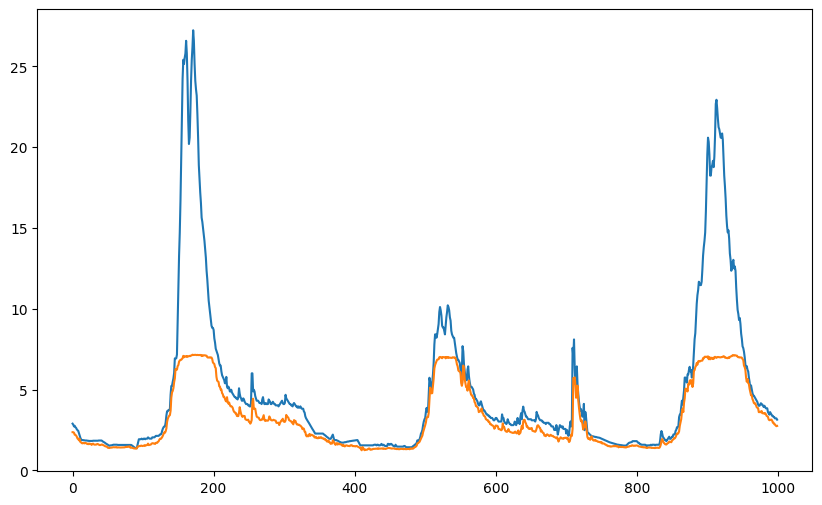

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(y_test[:1000])
plt.plot(y_preds[:1000])

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.figsize": (12, 4),        # bigger by default
    "font.size": 14,                  # readable from the back row
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "grid.linestyle": ":",
    "grid.linewidth": 0.75,
})

fig, ax = plt.subplots()

ax.plot(
    [i for i in range(2000, 3000)],
    y_test[2000:3000], 
    label="True", 
    linewidth=2.5
)

for i, model in enumerate(experiment.model_paths):
    booster = xgb.Booster()
    booster.load_model(model)
    y_preds = booster.predict(dtest)
    ax.plot(
    [i for i in range(2000, 3000)],
        y_preds[2000:3000], 
        label="Prediction" if i == 0 else None,
        linewidth=2.5, 
        linestyle="--",
        alpha=0.6,
        color="orange"
    )

ax.set_title("Gradient boosting prediction")
# ax.set_xlabel("Sample index")
# ax.set_ylabel("Value")
ax.grid(True)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("Gradient_prediction.pdf", format="pdf", bbox_inches="tight")

plt.close(fig)


In [52]:
forest_models = [name for name in Path("artifacts/Fast and Small/models/forest_50").iterdir()]
forest_models

[PosixPath('artifacts/Fast and Small/models/forest_50/model2025-05-18_113048.json'),
 PosixPath('artifacts/Fast and Small/models/forest_50/model2025-05-18_113315.json'),
 PosixPath('artifacts/Fast and Small/models/forest_50/model2025-05-18_113530.json')]

In [57]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.figsize": (12, 4),        # bigger by default
    "font.size": 14,                  # readable from the back row
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "grid.linestyle": ":",
    "grid.linewidth": 0.75,
})

fig, ax = plt.subplots()

ax.plot(
    [i for i in range(2000, 3000)],
    y_test[2000:3000], 
    label="True", 
    linewidth=2.5
)

for i, model in enumerate(forest_models):
    booster = xgb.Booster()
    booster.load_model(model)
    y_preds = booster.predict(dtest)
    ax.plot(
    [i for i in range(2000, 3000)],
        y_preds[2000:3000], 
        label="Prediction" if i == 0 else None,
        linewidth=2.5, 
        linestyle="--",
        alpha=0.6,
        color="orange"
    )

ax.set_title("Random forest prediction")
# ax.set_xlabel("Sample index")
# ax.set_ylabel("Value")
ax.grid(True)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("forest_prediction.pdf", format="pdf", bbox_inches="tight")

plt.close(fig)


In [55]:
import numpy as np
import xgboost as xgb
from pathlib import Path

def nse(y_true, y_pred):
    num = np.sum((y_true - y_pred) ** 2)
    den = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - num / den if den != 0 else np.nan

def mape(y_true, y_pred, eps=1e-12):
    mask = np.abs(y_true) > eps        # avoid division by ~0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# ---------- evaluation loop ----------
dtest = xgb.DMatrix(X_test)            # reuse existing test matrix
results = []                           # list of dicts per model

for model_path in Path("artifacts/Fast and Small/models/forest_50").glob("*.json"):
    booster = xgb.Booster()
    booster.load_model(model_path)
    y_pred = booster.predict(dtest)

    results.append({
        "model": model_path.name,
        "NSE" : nse(y_test, y_pred),
        "MAPE": mape(y_test, y_pred),
        "RMSE": rmse(y_test, y_pred),
        "MAE" : mae(y_test, y_pred),
    })

# Pretty print or convert to a DataFrame
from pprint import pprint
results


[{'model': 'model2025-05-18_113048.json',
  'NSE': -398.6169128417969,
  'MAPE': 1355.3627014160156,
  'RMSE': 60.82149,
  'MAE': 36.439434},
 {'model': 'model2025-05-18_113315.json',
  'NSE': -398.6666259765625,
  'MAPE': 1355.4526329040527,
  'RMSE': 60.825275,
  'MAE': 36.480297},
 {'model': 'model2025-05-18_113530.json',
  'NSE': -398.2633972167969,
  'MAPE': 1354.719066619873,
  'RMSE': 60.794582,
  'MAE': 36.458748}]

In [56]:
import pandas as pd
pd.DataFrame(results).drop(columns=["model"]).mean(axis=0)

NSE     -398.515645
MAPE    1355.178134
RMSE      60.813782
MAE       36.459492
dtype: float64

In [42]:
import numpy as np
import xgboost as xgb
from pathlib import Path

def nse(y_true, y_pred):
    num = np.sum((y_true - y_pred) ** 2)
    den = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - num / den if den != 0 else np.nan

def mape(y_true, y_pred, eps=1e-12):
    mask = np.abs(y_true) > eps        # avoid division by ~0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# ---------- evaluation loop ----------
dtest = xgb.DMatrix(X_test)            # reuse existing test matrix
results = []                           # list of dicts per model

for model_path in Path("artifacts/Fast and Small/models/boosting").glob("*.json"):
    booster = xgb.Booster()
    booster.load_model(model_path)
    y_pred = booster.predict(dtest)

    results.append({
        "model": model_path.name,
        "NSE" : nse(y_test, y_pred),
        "MAPE": mape(y_test, y_pred),
        "RMSE": rmse(y_test, y_pred),
        "MAE" : mae(y_test, y_pred),
    })

# Pretty print or convert to a DataFrame
from pprint import pprint
results


[{'model': 'model2025-05-18_094431.json',
  'NSE': 0.47283935546875,
  'MAPE': 26.955628395080566,
  'RMSE': 2.2090554,
  'MAE': 0.8505266},
 {'model': 'model2025-05-18_095413.json',
  'NSE': 0.4667809009552002,
  'MAPE': 27.02045440673828,
  'RMSE': 2.221713,
  'MAE': 0.8546919},
 {'model': 'model2025-05-18_095857.json',
  'NSE': 0.4754769802093506,
  'MAPE': 26.92475914955139,
  'RMSE': 2.2035222,
  'MAE': 0.8485526},
 {'model': 'model2025-05-18_093933.json',
  'NSE': 0.4661712646484375,
  'MAPE': 27.104276418685913,
  'RMSE': 2.222983,
  'MAE': 0.85664195},
 {'model': 'model2025-05-18_100352.json',
  'NSE': 0.463994562625885,
  'MAPE': 27.103528380393982,
  'RMSE': 2.2275105,
  'MAE': 0.85724676},
 {'model': 'model2025-05-18_094939.json',
  'NSE': 0.4731908440589905,
  'MAPE': 26.943546533584595,
  'RMSE': 2.208319,
  'MAE': 0.850142}]

In [48]:
import pandas as pd
pd.DataFrame(results).drop(columns=["model"]).mean(axis=0)

NSE      0.469742
MAPE    27.008699
RMSE     2.215517
MAE      0.852967
dtype: float64